# Task 1 – Data Acquisition: Download & Visualize EM Slices and Mito Masks

## Dataset

In [1]:
DATASET   = "jrc_hela-3"   # e.g. jrc_hela-3, jrc_cos7-11, jrc_mus-kidney, jrc_mus-liver
SCALE     = "s3"            # s0=full res, s1=half, s2=quarter, s3=eighth ...
N_SLICES  = 10               # number of evenly-spaced z-slices to download
N_SHOW    = 5               # how many slices to display (≤ N_SLICES)

## Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

# Add the download script to the path so we can reuse its functions
sys.path.insert(0, str(Path(".").resolve()))
from download import open_n5_group, find_array, download_slices, EM_CANDIDATES, MITO_CANDIDATES

## Download

In [3]:
DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(exist_ok=True)

em_cache   = DATA_DIR / f"{DATASET}_em_{SCALE}_{N_SLICES}slices.npy"
mito_cache = DATA_DIR / f"{DATASET}_mito_{SCALE}_{N_SLICES}slices.npy"

# EM — load from cache or download
if em_cache.exists():
    print(f"Loading cached EM: {em_cache}")
    em = np.load(em_cache)
else:
    print(f"Opening N5 container for '{DATASET}' ...")
    group = open_n5_group(DATASET)
    em_path, em_arr = find_array(group, EM_CANDIDATES, SCALE)
    if em_arr is None:
        raise RuntimeError(f"EM array not found at scale '{SCALE}' for dataset '{DATASET}'")
    print(f"EM path : {em_path}  shape={em_arr.shape}  dtype={em_arr.dtype}")
    print(f"Downloading {N_SLICES} EM slices ...")
    em = download_slices(em_arr, N_SLICES)
    np.save(em_cache, em)
    print(f"  -> {em.shape}  saved to {em_cache}")

# Mito — load from cache or download
if mito_cache.exists():
    print(f"Loading cached mito: {mito_cache}")
    mito = np.load(mito_cache)
else:
    if "group" not in dir():
        group = open_n5_group(DATASET)
    mito_path, mito_arr = find_array(group, MITO_CANDIDATES, SCALE)
    if mito_arr is None:
        print(f"WARNING: Mito segmentation not found at scale '{SCALE}'. Overlay will be skipped.")
        mito = None
    else:
        print(f"Mito path : {mito_path}  shape={mito_arr.shape}  dtype={mito_arr.dtype}")
        print(f"Downloading {N_SLICES} mito slices ...")
        mito = download_slices(mito_arr, N_SLICES)
        np.save(mito_cache, mito)
        print(f"  -> {mito.shape}  saved to {mito_cache}")

Loading cached EM: ../data/raw/jrc_hela-3_em_s3_10slices.npy
Loading cached mito: ../data/raw/jrc_hela-3_mito_s3_10slices.npy


## Helper functions

In [4]:
def normalize(arr):
    """Stretch contrast to [0, 1] using 1st/99th percentile."""
    a = arr.astype(np.float32)
    lo, hi = np.percentile(a, 1), np.percentile(a, 99)
    return np.clip((a - lo) / (hi - lo + 1e-8), 0, 1)

def match_shape(mask, target_shape):
    """Resize binary mask to target (H, W) if spatial dims differ."""
    if mask.shape == target_shape:
        return mask
    return resize(mask.astype(np.float32), target_shape, order=0, anti_aliasing=False) > 0.5

## 1 – Raw EM slices

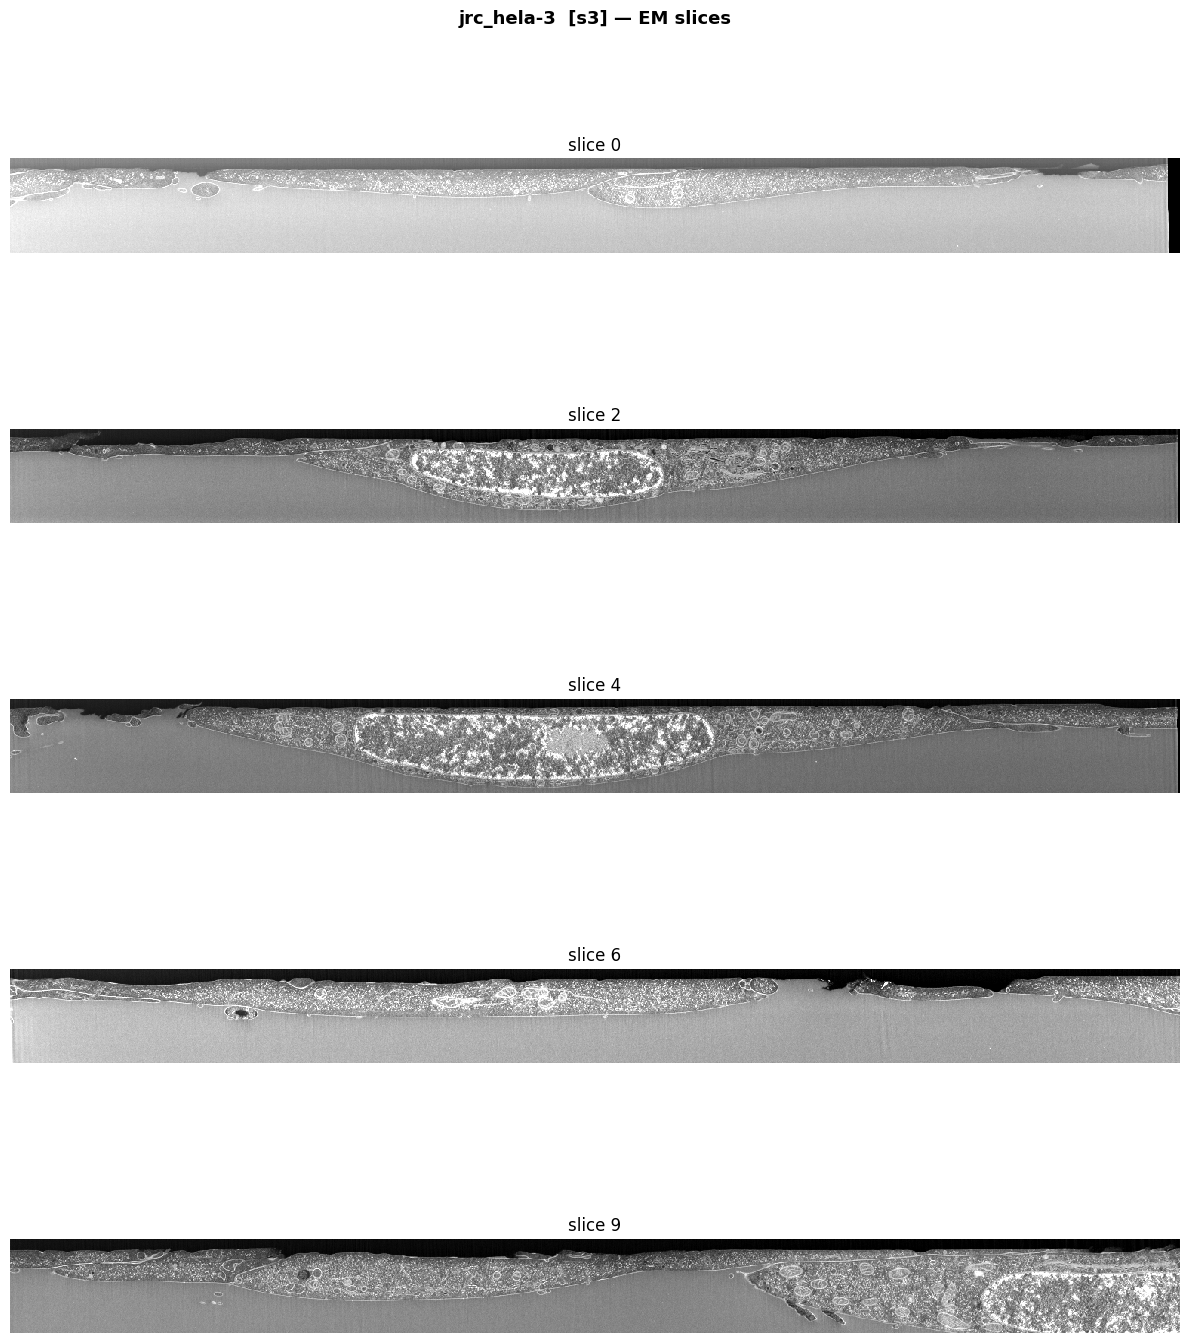

In [5]:
n = min(N_SHOW, len(em))
indices = np.linspace(0, len(em) - 1, n, dtype=int)

fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n))
fig.suptitle(f"{DATASET}  [{SCALE}] — EM slices", fontsize=13, fontweight="bold")
for ax, i in zip(np.atleast_1d(axes), indices):
    ax.imshow(normalize(em[i]), cmap="gray", interpolation="nearest")
    ax.set_title(f"slice {i}")
    ax.axis("off")
plt.tight_layout()
out_dir = Path("../outputs/task1")
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / f"task1_em_slices_{DATASET}_{SCALE}.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 – Mito segmentation masks

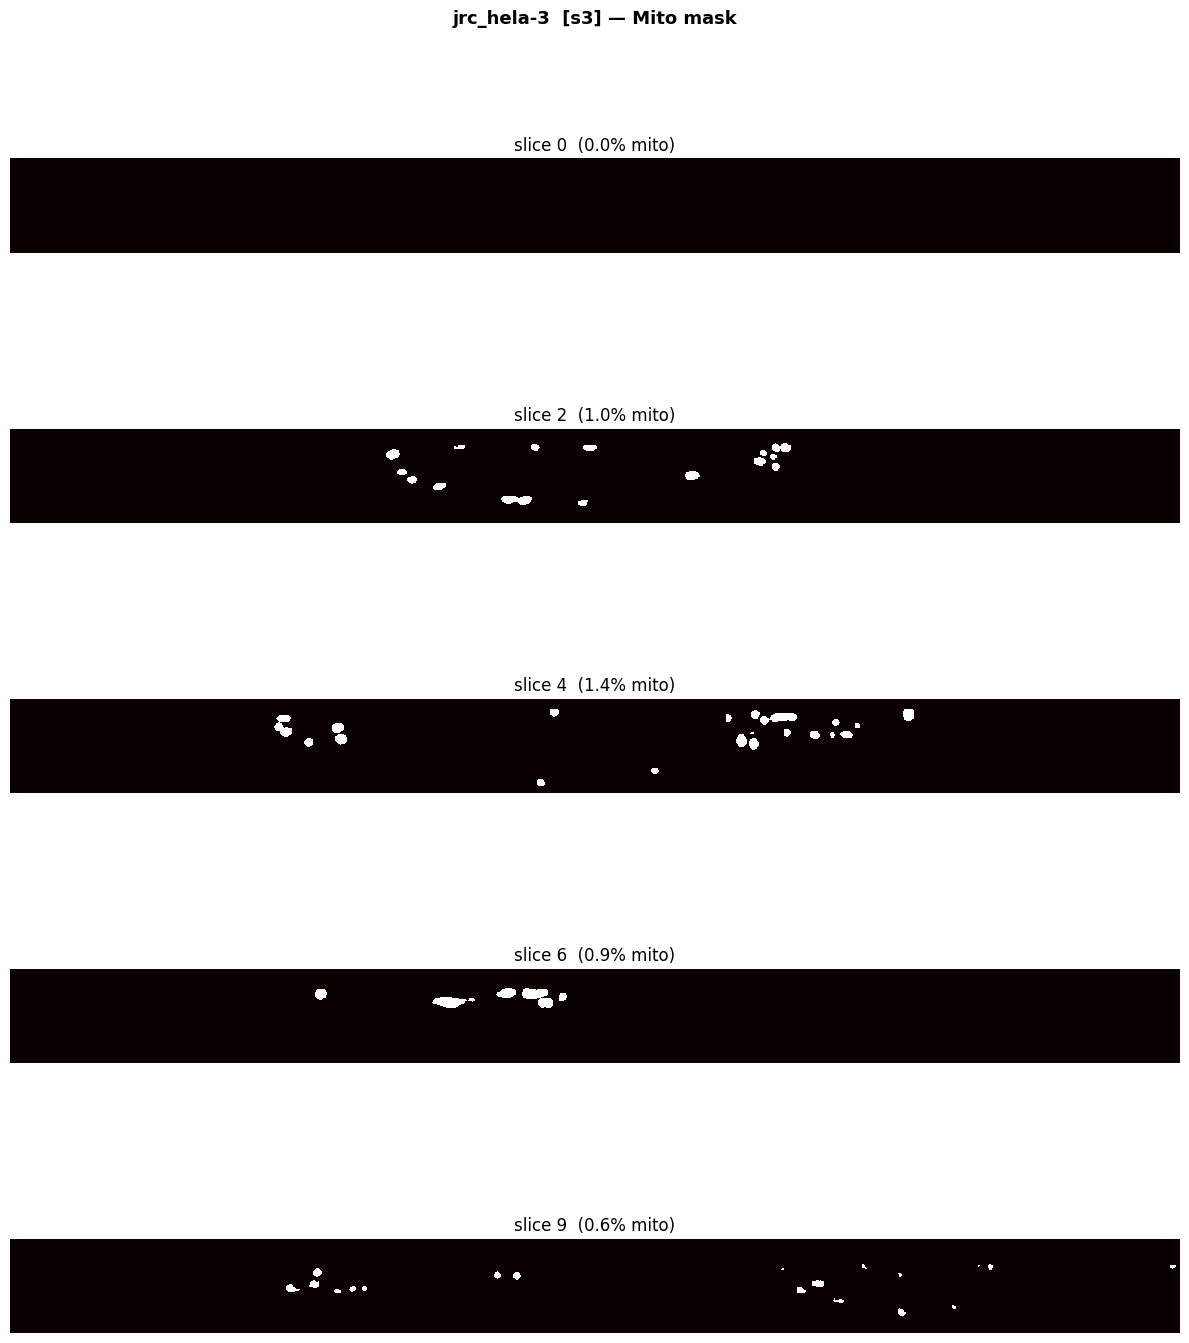

In [6]:
if mito is None:
    print("No mito segmentation available.")
else:
    n = min(N_SHOW, len(mito))
    indices = np.linspace(0, len(mito) - 1, n, dtype=int)

    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n))
    fig.suptitle(f"{DATASET}  [{SCALE}] — Mito mask", fontsize=13, fontweight="bold")
    for ax, i in zip(np.atleast_1d(axes), indices):
        binary = mito[i] > 0
        ax.imshow(binary, cmap="hot", interpolation="nearest")
        ax.set_title(f"slice {i}  ({binary.mean()*100:.1f}% mito)")
        ax.axis("off")
    plt.tight_layout()
    out_dir = Path("../outputs/task1")
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / f"task1_mito_mask_{DATASET}_{SCALE}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 3 – EM with mito overlay

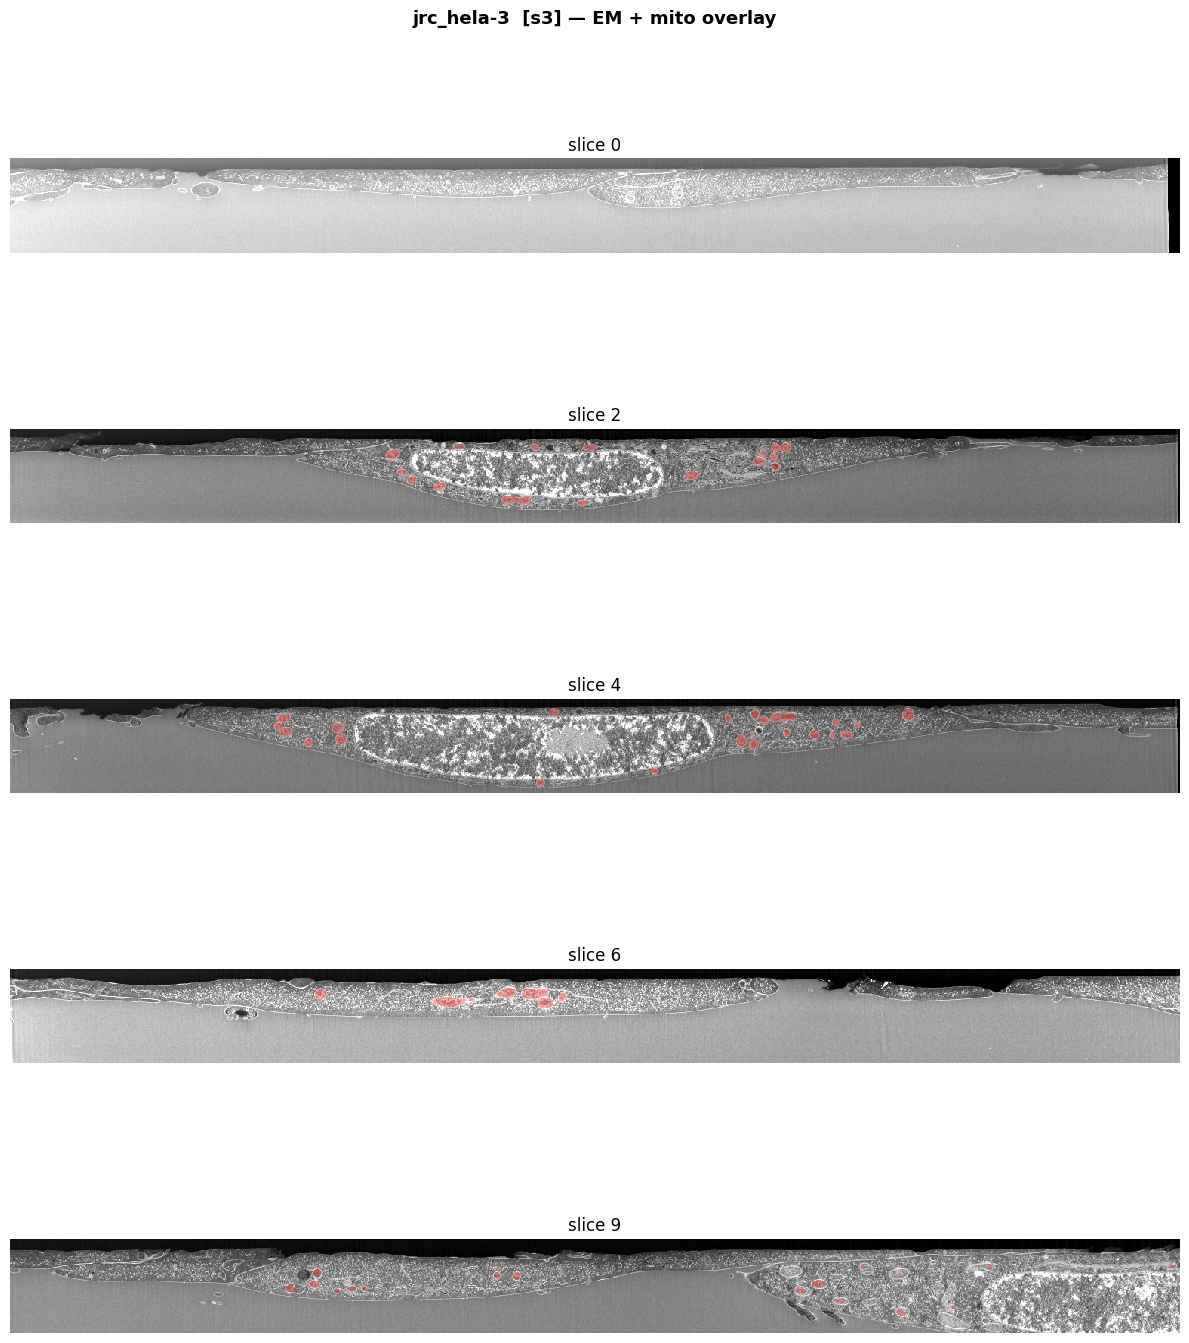

In [7]:
OVERLAY_ALPHA = 0.4
OVERLAY_COLOR = np.array([1.0, 0.2, 0.2])  # red

if mito is None:
    print("No mito segmentation available — skipping overlay.")
else:
    n = min(N_SHOW, len(em))
    em_idx   = np.linspace(0, len(em)   - 1, n, dtype=int)
    mito_idx = np.linspace(0, len(mito) - 1, n, dtype=int)

    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n))
    fig.suptitle(f"{DATASET}  [{SCALE}] — EM + mito overlay", fontsize=13, fontweight="bold")
    for ax, ei, mi in zip(np.atleast_1d(axes), em_idx, mito_idx):
        em_norm = normalize(em[ei])
        mask    = match_shape(mito[mi] > 0, em_norm.shape)
        rgb     = np.stack([em_norm] * 3, axis=-1)
        rgb[mask] = (1 - OVERLAY_ALPHA) * rgb[mask] + OVERLAY_ALPHA * OVERLAY_COLOR
        ax.imshow(rgb, interpolation="nearest")
        ax.set_title(f"slice {ei}")
        ax.axis("off")
    plt.tight_layout()
    out_dir = Path("../outputs/task1")
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / f"task1_em_overlay_{DATASET}_{SCALE}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4 – Mito size distribution

Unique mito instances : 88
Pixel count — min: 5  median: 124  max: 1582


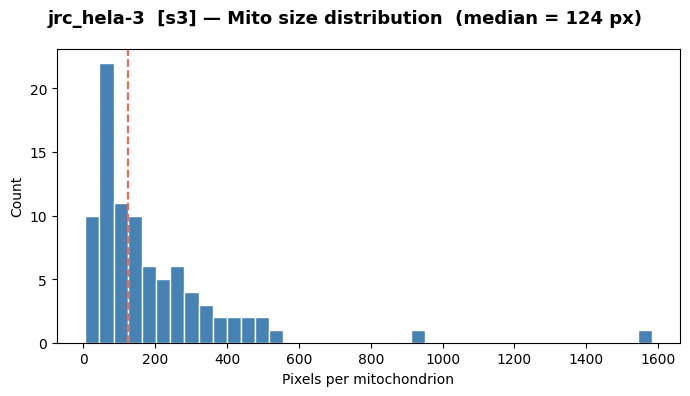

Figure saved to ../outputs/task1/task1_mito_size_dist_jrc_hela-3_s3.png


In [8]:
if mito is None:
    print("No mito segmentation available.")
else:
    from collections import Counter

    # Count pixels per mito ID across all slices (exclude background = 0)
    pixel_counts = Counter()
    for sl in mito:
        ids, counts = np.unique(sl, return_counts=True)
        for mid, cnt in zip(ids, counts):
            if mid != 0:
                pixel_counts[mid] += cnt

    sizes = np.array(list(pixel_counts.values()))
    print(f"Unique mito instances : {len(sizes)}")
    print(f"Pixel count — min: {sizes.min()}  median: {int(np.median(sizes))}  max: {sizes.max()}")

    fig, ax = plt.subplots(figsize=(7, 4))
    median = int(np.median(sizes))

    fig.suptitle(f"{DATASET}  [{SCALE}] — Mito size distribution  (median = {median} px)",
                 fontsize=13, fontweight="bold")

    ax.hist(sizes, bins=40, color="steelblue", edgecolor="white")
    ax.axvline(median, color="tomato", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Pixels per mitochondrion")
    ax.set_ylabel("Count")

    plt.tight_layout()
    out_dir = Path("../outputs/task1")
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = out_dir / f"task1_mito_size_dist_{DATASET}_{SCALE}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {fname}")